In [1]:
import sys, pdb, string,os, glob
sys.path.append('../gizmo_analysis/pysrc/')
import my_utils as u
import numpy as np
from numpy import log10 as log, log as ln
import h5py
from scipy import interpolate
import astropy, astropy.cosmology
from astropy import units as un, constants as cons
from astropy.cosmology import Planck15 as cosmo
import pylab as pl, matplotlib
from matplotlib import cm, ticker
homedir = os.environ["HOME"]
#projectdir = homedir+'/Dropbox/github_repositories/cgm_models/TurbDominated/'
#import my_utils as u

In [2]:
from projectPlotBasics import *

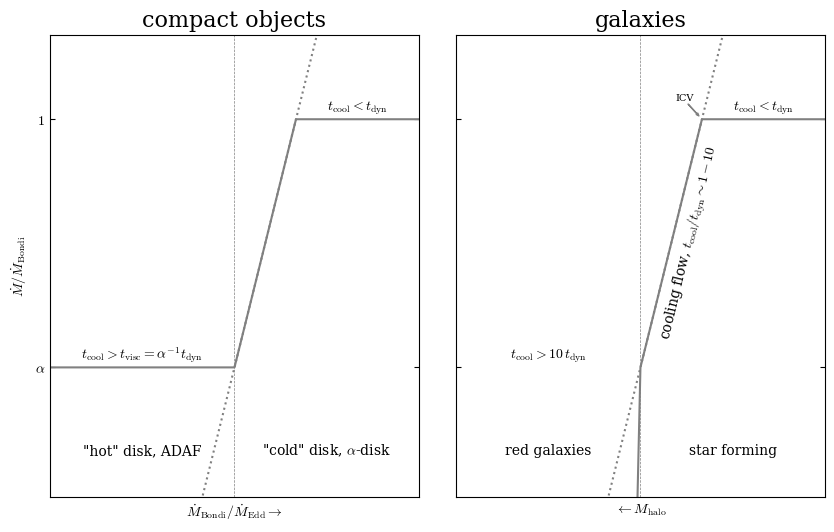

In [3]:
alpha = 30**-1.
xs = np.array([-10,-4,-2,2])
ys = log(np.array([alpha,alpha,1,1]))

fig = pl.figure(figsize=(10,6))
pl.subplots_adjust(wspace=0.1)
ax=pl.subplot(121)
pl.plot(xs,ys,c='.5')
u.plotLine((ys[2]-ys[1])/(xs[2]-xs[1]),throughPoint=(xs[2],ys[2]),ls=':',c='.5')
ax.yaxis.set_ticks([ys[0],ys[-1]],[r'$\alpha$',r'$1$'])
ax.xaxis.set_major_locator(ticker.NullLocator())
pl.text(xs[:2].mean(),-2,r'"hot" disk, ADAF',ha='center')
pl.text(xs[:2].mean(),ys[0]+0.05,r"$t_{\rm cool} > t_{\rm visc}=\alpha^{-1}t_{\rm dyn}$",ha='center')
pl.text(xs[1::2].mean(),-2,r'"cold" disk, $\alpha$-disk',ha='center')
pl.text(xs[2:].mean(),ys[-1]+0.05,r"$t_{\rm cool} < t_{\rm dyn}$",ha='center')
pl.ylim(-2.25,0.5)
pl.xlim(xs[0],xs[-1])
pl.axvline(xs[1],lw=0.5,c='.5',ls='--')
pl.ylabel(r'$\dot{M}/\dot{M}_{\rm Bondi}$')
pl.xlabel(r'$\dot{M}_{\rm Bondi}/\dot{M}_{\rm Edd} \rightarrow$')
pl.title(r'compact objects',fontsize=16)

ys = log(np.array([1e-50,alpha,1,1]))

ax=pl.subplot(122)
pl.plot(xs,ys,c='.5')
u.plotLine((ys[2]-ys[1])/(xs[2]-xs[1]),throughPoint=(xs[2],ys[2]),ls=':',c='.5')
ax.xaxis.set_major_locator(ticker.NullLocator())
ax.yaxis.set_ticks([ys[1],ys[-1]],[r'',r''])
pl.text(xs[:2].mean(),-2,r'red galaxies',ha='center')
pl.text(xs[:2].mean(),ys[1]+0.05,r"$t_{\rm cool} > 10\,t_{\rm dyn}$",ha='center')
pl.text(xs[1::2].mean(),-2,r'star forming',ha='center')
pl.text(xs[2:].mean(),ys[-1]+0.05,r"$t_{\rm cool} < t_{\rm dyn}$",ha='center')
pl.text(xs[1:3].mean()+0.6,ys[1:3].mean(), r'cooling flow, $t_{\rm cool}/t_{\rm dyn}\sim 1-10$',rotation=76.5,ha='center',va='center')
pl.annotate('ICV',(xs[2]-0.2,ys[2]+0.04),(xs[2]-0.25,ys[2]+0.1),fontsize=7,ha='right',va='bottom')
pl.annotate('',(xs[2]-0.1,ys[2]+0.02),(xs[2]-0.45,ys[2]+0.09),fontsize=7,ha='right',va='bottom',arrowprops=slantlineprops)
pl.ylim(-2.25,0.5)
pl.xlim(xs[0],xs[-1])
pl.axvline(xs[1],lw=0.5,c='.5',ls='--')
pl.xlabel(r'$\leftarrow M_{\rm halo}$')
pl.title(r'galaxies',fontsize=16)
pl.savefig('CompactObjectAnalogy.pdf')

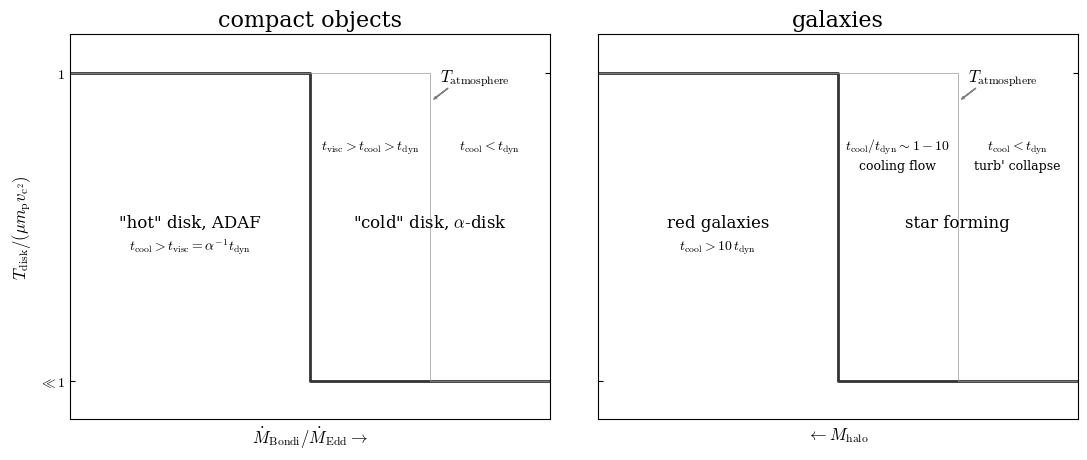

In [4]:
alpha = 30**-1.
xs = np.array([-10,-4,-4,2])
ys = log(np.array([1,1,0.01,0.01]))
xs2 = np.array([-10,-1,-1,2])

fig = pl.figure(figsize=(13,5))
pl.subplots_adjust(wspace=0.1)
ax=pl.subplot(121)
pl.plot(xs,ys,c='.2',label='disk',lw=2)
pl.plot(xs2,ys,c='.6',lw='0.5',label='atmosphere')
ax.yaxis.set_ticks([ys[0],ys[-1]],[r'$1$',r'$\ll1$'])
ax.xaxis.set_major_locator(ticker.NullLocator())
pl.text(xs[:2].mean(),ys.mean(),r'"hot" disk, ADAF',ha='center',fontsize=12)
pl.text(xs[:2].mean(),ys.mean()-0.15,r"$t_{\rm cool}> t_{\rm visc}=\alpha^{-1}t_{\rm dyn}$",ha='center')
pl.text(xs[1::2].mean(),ys.mean(),r'"cold" disk, $\alpha$-disk',ha='center',fontsize=12)
pl.xlim(xs[0],xs[-1])
pl.ylim(-2.25,0.25)
pl.ylabel(r'$T_{\rm disk}/ (\mu m_{\rm p}v_{\rm c^2})$',fontsize=12)
pl.xlabel(r'$\dot{M}_{\rm Bondi}/\dot{M}_{\rm Edd} \rightarrow$',fontsize=12)
pl.title(r'compact objects',fontsize=16)
pl.annotate(r'$T_{\rm atmosphere}$',(xs2[2]+0.2,-0.17),(xs2[2]+0.25,-0.1),fontsize=12,ha='left',va='bottom')
pl.annotate('',(xs2[2]+0.1,-0.17),(xs2[2]+0.45,-0.1),ha='left',va='bottom',arrowprops=slantlineprops)
pl.text(xs2[2:].mean(),-0.5,r"$t_{\rm cool}<t_{\rm dyn}$",ha='center')
pl.text(np.mean([xs2[1],xs[1]]),-0.5,r"$t_{\rm visc} > t_{\rm cool} > t_{\rm dyn}$",ha='center')

ax=pl.subplot(122)
pl.plot(xs,ys,c='.2',label='disk',lw=2)
pl.plot(xs2,ys,c='.6',lw='0.5',label='atmosphere')
ax.yaxis.set_ticks([ys[1],ys[-1]],[r'',r''])
ax.xaxis.set_major_locator(ticker.NullLocator())
pl.text(xs[:2].mean(),ys.mean(),r'red galaxies',ha='center',fontsize=12)
pl.text(xs[:2].mean(),ys.mean()-0.15,r"$t_{\rm cool}>10\,t_{\rm dyn}$",ha='center')
pl.text(xs[1::2].mean(),ys.mean(),r'star forming',ha='center',fontsize=12)
pl.xlim(xs[0],xs[-1])
pl.ylim(-2.25,0.25)
pl.xlabel(r'$\leftarrow M_{\rm halo}$',fontsize=12)
pl.title(r'galaxies',fontsize=16)
pl.annotate(r'$T_{\rm atmosphere}$',(xs2[2]+0.2,-0.17),(xs2[2]+0.25,-0.1),fontsize=12,ha='left',va='bottom')
pl.annotate('',(xs2[2]+0.1,-0.17),(xs2[2]+0.45,-0.1),ha='left',va='bottom',arrowprops=slantlineprops)
pl.text(xs2[2:].mean(),-0.5,r"$t_{\rm cool}<t_{\rm dyn}$",ha='center')
pl.text(xs2[2:].mean(),-0.6, r"turb' collapse",ha='center',va='center',fontsize=9)
pl.text(np.mean([xs2[1],xs[1]]),-0.5,r"$t_{\rm cool}/ t_{\rm dyn}\sim1-10$",ha='center')
pl.text(np.mean([xs2[1],xs[1]]),-0.6, r'cooling flow',ha='center',va='center',fontsize=9)
#pl.annotate('ICV',(xs[2]+0.2,ys[2]+0.04),(xs2[2]-0.25,ys[2]+0.1),fontsize=10,ha='left',va='bottom')
pl.savefig('CompactObjectAnalogy_temperature.pdf')

In [ ]:
#tcool >> alpha^-1 t_ff: adiabatic radial inflow + ADAF
#alpha_P~ 1/gamma vc^2 / c_s2
#alpha_rho ~ vc^2/cs^2
#alpha_T ~ 2/3 vc^2/cs^2
#t_ff < tcool < alpha^-1 t_ff: cooling flow + star forming disk
# rho ~ r^-1.5, T~const, v_r ~ r^-0.5 
#tcool < tff: turbulent collapse + irregular disk
# rho ~ r^-2, T~10^4, v_r ~ v_c

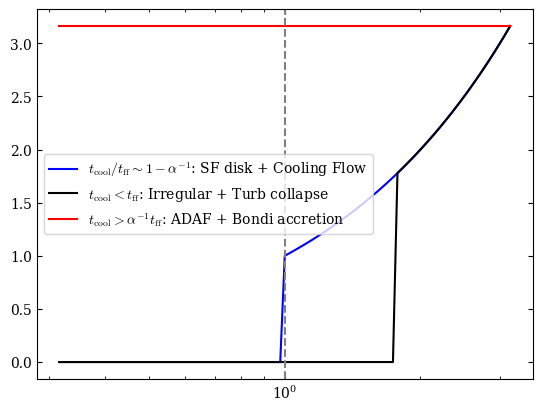

In [21]:
rs = 10.**np.arange(-0.5,0.505,0.01)
l = rs.shape[0]
floor = 1e-5
Ks_CF = np.concatenate([[floor]*((l-1)//2), rs[(l-1)//2:]])
Ks_turb = np.concatenate([[floor]*((l-1)*3//4), rs[((l-1)*3//4):]])
Ks_Bondi = np.ones(rs.shape[0])*rs[-1]
pl.plot(rs,Ks_CF,c='b',label=r'$t_{\rm cool}/t_{\rm ff} \sim 1 -\alpha^{-1}$: SF disk + Cooling Flow')
pl.plot(rs,Ks_turb,c='k',label=r'$t_{\rm cool}<t_{\rm ff}$: Irregular + Turb collapse')
pl.plot(rs,Ks_Bondi,c='r',label=r'$t_{\rm cool}>\alpha^{-1}t_{\rm ff}$: ADAF + Bondi accretion')
pl.semilogx()
pl.axvline(1,c='.5',ls='--')
pl.legend()